In [1]:
import os
import openmc
import numpy as np
from IPython.display import Image, display
import matplotlib.pyplot as plt

In [2]:
# pulizia per sicurezza

#os.system("rm *.h5")
os.system("rm summary.h5")
os.system("rm *.xml")
os.system("rm *.out")
os.system("rm *.png")

rm: cannot remove ‘summary.h5’: No such file or directory
rm: cannot remove ‘*.out’: No such file or directory


0

In [3]:
# VARIABILI DA PAPERMILL se serve (verranno sovrascritte)
pressione_atm = 1.0
moltiplicatore = 1.0
perc_water = 0.15
arricch_max =  45.812 # in percentuale
arricch_min = 5  # in percentuale
t_water = 350.0
t_fuel = 600.0
run_id = "default"

VARIABILI IMPORTANTI

In [4]:
def load_parameters(filename='parametri.txt'):
    """
    Legge i parametri dal file txt e li restituisce come un dizionario.
    """
    params = {}
    # Forniamo np al contesto di esecuzione per gestire np.sqrt()
    context = {'np': np} 
    
    with open(filename, 'r') as f:
        code = f.read()
        exec(code, context, params)
    
    # Rimuoviamo 'np' e altri built-in dal dizionario finale
    return {k: v for k, v in params.items() if not k.startswith('__') and k != 'np'}

p = load_parameters("parametri.txt")

# --- Parametri Geometrici e Logici ---
R_CORE    = p['R_CORE']*moltiplicatore
REF_SIDE  = p['REF_SIDE']
REF_BOT   = p['REF_BOT']
H_CORE    = p['H_CORE']
R_PIPE    = p['R_PIPE']

# --- Parametri Target e Sorgente ---
R_TARGET  = p['R_TARGET']
H_TARGET  = p['H_TARGET']
P_TARGET  = p['P_TARGET']
S         = p['S']
bin_ris   = p['bin_ris']
batches   = p['batches_auto']
particles = p['particles_auto']
inactive      = p['inactive_auto']


# --- Parametri Pin/Lattice Base ---
R_FUEL    = p['R_FUEL']
CLAD_THICK= p['CLAD_THICK']
R_WATER_THICK = p['R_WATER_THICK']
R_PIN     = p['R_PIN']

enrich_target = p['enrich_target']

# ==========================================
# SOVRASCRITTURA CON PARAMETRI DI PAPERMILL
# ==========================================
Pressione_funzionamento = pressione_atm * 101325  # atm in Pa
PITCH     = p['PITCH'] * moltiplicatore
mix       = perc_water
T_water   = t_water
T_resto   = t_fuel

# I valori dal txt sono in percentuale, convertiamoli in frazione
enrich_max = arricch_max / 100.0
enrich_min = arricch_min / 100.0


In [5]:
from CoolProp.CoolProp import PropsSI

def densita_mix_dinamica(T_K, P_Pa= Pressione_funzionamento, frac_mass_H2O=mix):
    # Calcolo in kg/m^3 e conversione in g/cm^3
    rho_H2O = PropsSI('D', 'T', T_K, 'P', P_Pa, 'Water') / 1000     # D sta per densità
    rho_D2O = PropsSI('D', 'T', T_K, 'P', P_Pa, 'HeavyWater') / 1000
    
    # Calcolo miscela assumendo volumi ideali additivi
    rho_mix = 1 / (frac_mass_H2O / rho_H2O + (1 - frac_mass_H2O) / rho_D2O) # Formula di additività dei volumi specifici
    return rho_mix

print(f"Densità del mix a {T_water} K e {Pressione_funzionamento/1e6} MPa: {densita_mix_dinamica(T_water, Pressione_funzionamento, mix):.4f} g/cm^3")

Densità del mix a 350.0 K e 0.101325 MPa: 1.0629 g/cm^3


MATERIALI

In [6]:
# materiale di rivestimento
cladding = openmc.Material(name='cladding')
cladding.temperature = T_resto
cladding.add_element('Zr', 1.0) 
cladding.set_density('g/cm3', 6.49)

# materiale di moderatore
water = openmc.Material(name='water')
water.temperature = T_water
water.add_nuclide('H1', mix)
water.add_nuclide('H2', 1-mix)
water.add_element('O', 1.0)
water.set_density('g/cm3', densita_mix_dinamica(T_water)) # Usa la densità corretta
water.add_s_alpha_beta('c_D_in_D2O') 
water.add_s_alpha_beta('c_H_in_H2O') 

# aggiungo un riflettore 
reflector = openmc.Material(name='reflector')
reflector.temperature = T_resto
reflector.add_element('C', 1.0)
reflector.set_density('g/cm3', 1.75) 

# voglio una sorgente puntiforme di neutroni in un punto specifico
marker_mat = openmc.Material(name='marker')
marker_mat.temperature = T_resto
marker_mat.set_density('g/cm3', 1e-10) 
marker_mat.add_nuclide('He4', 1.0) 

void_air = openmc.Material(name='void_air')
void_air.temperature = T_resto
void_air.set_density('g/cm3', 1e-10) 
void_air.add_nuclide('N14', 1)

mat_target = openmc.Material(name='mat_target')
mat_target.temperature = T_resto
mat_target.add_nuclide('U235', enrich_target)
mat_target.add_nuclide('U238', 1.0 - enrich_target)
mat_target.add_nuclide('O16', 2.0)
mat_target.set_density('g/cm3', 10.96)
mat_target.volume = np.pi * (R_TARGET**2) * H_TARGET
mat_target.depletable = False

GEOMETRIA

In [7]:
# --- 0. FUNZIONI E CALCOLO NUMERO BARRE ---
import numpy as np

def count_fuel_pins(num_rings, pitch, r_pipe, r_core):
    total_pins = 0
    for i in range(num_rings):
        ring_radius = i * pitch
        if ring_radius >= r_pipe and r_core >= ring_radius:
            total_pins += 1 if i == 0 else (6 * i)
    return total_pins

num_rings = int(np.ceil(R_CORE / PITCH)) + 1
n_barre = count_fuel_pins(num_rings, PITCH, R_PIPE, R_CORE)
print(f"Numero di barre di combustibile effettive: {n_barre}")

# --- 1. PIANI Z (ASSOLUTI) ---
z_bot_ref = openmc.ZPlane(z0=-REF_BOT, boundary_type='vacuum')
z_bot_core = openmc.ZPlane(z0=0.0)
z_top_core = openmc.ZPlane(z0=H_CORE)
z_top_world = openmc.ZPlane(z0=H_CORE + 5.0, boundary_type='vacuum')

# Piani Z Target
z_mid = H_CORE - P_TARGET
z_tgt_bot = openmc.ZPlane(z0=z_mid - (H_TARGET / 2.0))
z_tgt_top = openmc.ZPlane(z0=z_mid + (H_TARGET / 2.0))

# Superficie Sorgente
sphere_src = openmc.Sphere(x0=0, y0=0, z0=H_CORE + 2, r=0.5)

# --- 2. CALCOLO DIMENSIONI E VOLUMI PER DEPLETION ---
n_rings_removed = int(np.ceil(R_PIPE / PITCH))
EDGE_PIPE_LARGE = (n_rings_removed - 0.5) * PITCH
if EDGE_PIPE_LARGE == 0: EDGE_PIPE_LARGE = PITCH

hex_core_edge = num_rings * PITCH
hex_ref_edge = hex_core_edge + REF_SIDE

# Aree esagonali base
A_core = 1.5 * np.sqrt(3) * (hex_core_edge**2)
A_pipe = 1.5 * np.sqrt(3) * (EDGE_PIPE_LARGE**2)
A_ref  = 1.5 * np.sqrt(3) * (hex_ref_edge**2)

# Assegnazione volumi
V_clad_single = np.pi * ((R_FUEL + CLAD_THICK)**2 - R_FUEL**2) * H_CORE
cladding.volume = n_barre * V_clad_single
cladding.depletable = False

V_pins_total = n_barre * np.pi * ((R_FUEL + CLAD_THICK)**2) * H_CORE
water.volume = (A_core - A_pipe) * H_CORE - V_pins_total
water.depletable = False

V_ref_side = (A_ref - A_core) * H_CORE
V_ref_bot  = A_ref * REF_BOT
reflector.volume = V_ref_side + V_ref_bot
reflector.depletable = False

# --- 3. FORME GEOMETRICHE BASE ---
EDGE_FUEL = R_FUEL
EDGE_CLAD = R_FUEL + CLAD_THICK

hex_fuel_prism = openmc.model.hexagonal_prism(edge_length=EDGE_FUEL, orientation='x')
hex_clad_prism = openmc.model.hexagonal_prism(edge_length=EDGE_CLAD, orientation='x')
hex_pipe_prism = openmc.model.hexagonal_prism(edge_length=EDGE_PIPE_LARGE, orientation='x')
cyl_target = openmc.ZCylinder(r=R_TARGET)

# --- 4. UNIVERSI COMBUSTIBILE ---
fuel_mats = []
fuel_universes = []
V_single_pin = np.pi * (R_FUEL**2) * H_CORE

for i in range(num_rings):
    if num_rings > 1:
        e_i = enrich_max - (enrich_max - enrich_min) * (i / (num_rings - 1))
    else:
        e_i = enrich_max

    f = openmc.Material(name=f'fuel_ring_{i}')
    f.temperature = T_resto
    f.add_nuclide('U235', e_i)
    f.add_nuclide('U238', 1.0 - e_i)
    f.add_nuclide('O16', 2.0)
    f.set_density('g/cm3', 10.96)
    
    ring_radius = i * PITCH
    if ring_radius >= R_PIPE and ring_radius <= R_CORE: 
        n_pins_in_ring = 6 * i if i > 0 else 1
        f.volume = n_pins_in_ring * V_single_pin
        f.depletable = True
    else:
        f.depletable = False

    fuel_mats.append(f)
    
    c_f = openmc.Cell(fill=f, region=hex_fuel_prism)
    c_c = openmc.Cell(fill=cladding, region=hex_clad_prism & ~hex_fuel_prism)
    c_w = openmc.Cell(fill=water, region=~hex_clad_prism)
    fuel_universes.append(openmc.Universe(cells=[c_f, c_c, c_w]))

# --- 5. ESPORTAZIONE MATERIALI ---
materials = openmc.Materials(fuel_mats + [cladding, water, reflector, marker_mat, void_air, mat_target])

materials.export_to_xml()

# --- 6. LATTICE E ASSEMBLAGGIO FINALE ---
c_water_full = openmc.Cell(fill=water)
u_water = openmc.Universe(cells=[c_water_full])

lattice_universes = []
for i in range(num_rings):
    if i == 0:
        lattice_universes.append([fuel_universes[i]])
    else:
        lattice_universes.append([fuel_universes[i]] * (6 * i))

lattice = openmc.HexLattice(name='core_hex_lattice')
lattice.center = (0.0, 0.0)
lattice.pitch = (PITCH,)
lattice.outer = u_water
lattice.universes = lattice_universes[::-1] 
lattice.orientation = 'x'

prism_core = openmc.model.hexagonal_prism(edge_length=hex_core_edge, orientation='x')
prism_reflector = openmc.model.hexagonal_prism(edge_length=hex_ref_edge, orientation='x', boundary_type='vacuum')

region_core = prism_core & ~hex_pipe_prism & +z_bot_core & -z_top_core
c_main_core = openmc.Cell(fill=lattice, region=region_core)

region_central_hex_total = hex_pipe_prism & +z_bot_core & -z_top_core
region_target_solid = region_central_hex_total & -cyl_target & +z_tgt_bot & -z_tgt_top
region_void_gap = region_central_hex_total & ~region_target_solid

c_target = openmc.Cell(fill=mat_target, region=region_target_solid)
c_void_gap = openmc.Cell(fill=void_air, region=region_void_gap) 

region_ref_side = prism_reflector & ~prism_core & +z_bot_core & -z_top_core
c_ref_side = openmc.Cell(fill=reflector, region=region_ref_side)

region_ref_bot = prism_reflector & +z_bot_ref & -z_bot_core
c_ref_bot = openmc.Cell(fill=reflector, region=region_ref_bot)

c_source_marker = openmc.Cell(fill=marker_mat, region=-sphere_src)
region_top = prism_reflector & +z_top_core & -z_top_world & +sphere_src
c_top_void = openmc.Cell(fill=void_air, region=region_top)

all_cells = [c_main_core, c_target, c_void_gap, c_ref_side, c_ref_bot, c_source_marker, c_top_void]
geometry = openmc.Geometry(all_cells)
geometry.export_to_xml()
print("Geometria generata correttamente.")

Numero di barre di combustibile effettive: 390
Geometria generata correttamente.


/raid1/users/rbossi/miniforge3/envs/openmc-env/lib/python3.11/site-packages/openmc/model/funcs.py:121: FutureWarning: The hexagonal_prism(...) function has been replaced by the HexagonalPrism(...) class. Future versions of OpenMC will not accept hexagonal_prism.
  warn("The hexagonal_prism(...) function has been replaced by the "


PLOTTING

/raid1/users/rbossi/miniforge3/envs/openmc-env/lib/python3.11/site-packages/openmc/plots.py:1307: FutureWarning: The Plot class is deprecated. Use SlicePlot for 2D slice plots or VoxelPlot for 3D voxel plots.
  warnings.warn(



VISUALIZZAZIONE GEOMETRIA

1. VISTA DALL'ALTO (Piano XY nel Core)


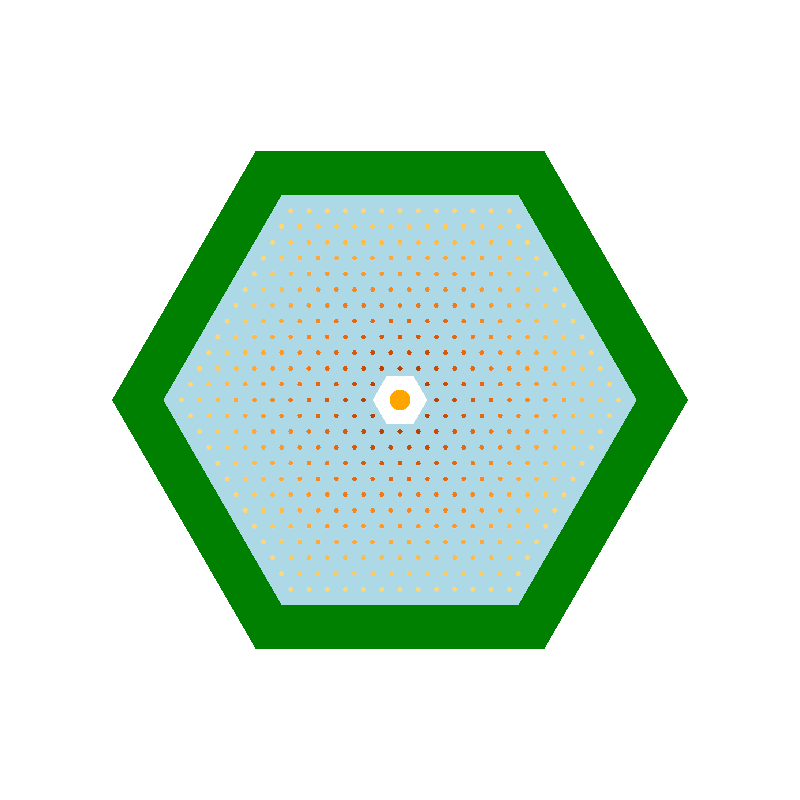

2. VISTA LATERALE (Piano XZ)


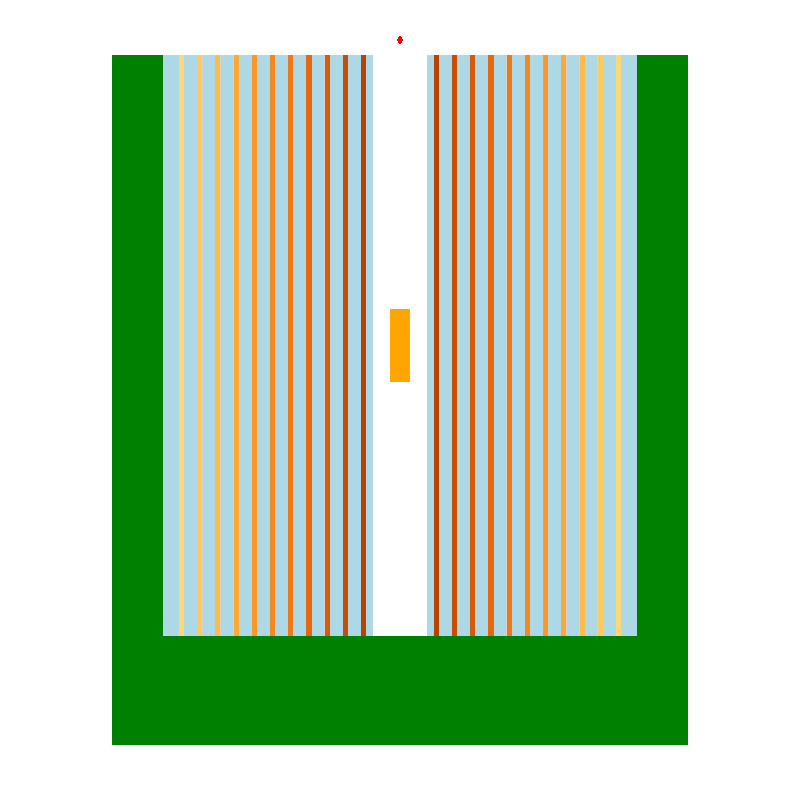

In [8]:
color_map = {
    cladding: 'lightgray',  # Cladding
    water: 'lightblue',     # Moderatore (acqua)
    reflector: 'green',     # Riflettore
    marker_mat: 'red' ,     # Marker sorgente
    void_air: 'white',      # Vuoto (aria)
    mat_target: 'orange'   # Target
}

cmap = plt.get_cmap('YlOrBr')

for i, f in enumerate(fuel_mats):
    if num_rings > 1:
        # Normalizziamo l'indice: 0 (centro, max arricchimento) -> 1 (esterno, min arricchimento)
        norm_val = i / (num_rings - 1)
    else:
        norm_val = 0.5
        
    rgba = cmap(0.9 - norm_val * 0.6)
    
    # OpenMC richiede tuple RGB con valori interi 0-255
    rgb_color = (int(rgba[0]*255), int(rgba[1]*255), int(rgba[2]*255))
    color_map[f] = rgb_color

# A. Vista dall'alto (Sezione nel mezzo del core)
p1 = openmc.Plot()
p1.basis = 'xy'
p1.origin = (0.0, 0.0, H_CORE / 2.0)
p1.width = (3 * (R_CORE + REF_SIDE + 2.0), 3 * (R_CORE + REF_SIDE + 2.0))
p1.pixels = (800, 800)
p1.color_by = 'material'
p1.colors = color_map
p1.filename = 'reactor_xy'

# B. Vista laterale (Sezione verticale XZ)
p2 = openmc.Plot()
p2.basis = 'xz'
p2.origin = (0.0, 0.0, (H_CORE - REF_BOT) / 2.0) 
p2.width = (3 * (R_CORE + REF_SIDE + 2.0), H_CORE + REF_BOT + 15.0)
p2.pixels = (800, 800)
p2.color_by = 'material'
p2.colors = color_map
p2.filename = 'reactor_xz'

# Esporto tutti i plot nel file XML
plots = openmc.Plots([p1, p2])
plots.export_to_xml()

# Eseguo il plotter: ho rimosso open_browser=False che causava l'errore
# OpenMC genererà i file .png basandosi sui nomi definiti (reactor_xy.png, ecc.)
openmc.plot_geometry() 

print("\n" + "="*30)
print("VISUALIZZAZIONE GEOMETRIA")
print("="*30 + "\n")

print("1. VISTA DALL'ALTO (Piano XY nel Core)")
display(Image('reactor_xy.png'))

print("2. VISTA LATERALE (Piano XZ)")
display(Image('reactor_xz.png'))

SETTINGS FIXED

In [9]:
settings_k = openmc.Settings()
settings_k.run_mode = 'eigenvalue'
settings_k.batches = batches
settings_k.particles = particles
settings_k.inactive = inactive

# Definizione del volume di ricerca strettamente confinato al pellet
r_search = R_FUEL 
lower_left = [-r_search, -r_search, -50]
upper_right = [r_search, r_search, 50]

# only_fissionable assicura il campionamento esclusivo nel materiale fissile
source_area = openmc.stats.Box(lower_left, upper_right, only_fissionable=True)

# Assegnazione rigorosa del dominio spaziale alla sorgente indipendente
settings_k.source = openmc.IndependentSource(space=source_area)

# Abbassamento della soglia di rigetto per geometrie critiche
settings_k.source_rejection_fraction = 1e-6 
settings_k.temperature = {'method': 'interpolation'}

# Esportazione
settings_k.export_to_xml()

/raid1/users/rbossi/miniforge3/envs/openmc-env/lib/python3.11/site-packages/openmc/stats/multivariate.py:960: FutureWarning: The 'only_fissionable' has been deprecated. Use the 'constraints' argument when defining a source instead.
  warn("The 'only_fissionable' has been deprecated. Use the "


TALLIES

In [10]:
tallies = openmc.Tallies()
#
## --- A. MESH E TALLY ASSIALE ---
#mesh_z = openmc.RegularMesh()
#mesh_z.dimension = [1, 1, bin_ris]
#mesh_z.lower_left = [-R_CORE, -R_CORE, 0.0]
#mesh_z.upper_right = [R_CORE, R_CORE, H_CORE]
#
## --- B. MESH E TALLY 2D (MAPPA FISSIONI) ---
#bound_xy = R_CORE + REF_SIDE 
#mesh_2d = openmc.RegularMesh()
#mesh_2d.dimension = [bin_ris, bin_ris, 1]
#mesh_2d.lower_left = [-bound_xy, -bound_xy, H_CORE/2.0 - 0.25] # mesh su una fetta alta 0.5 cm al centro del core
#mesh_2d.upper_right = [bound_xy, bound_xy, H_CORE/2.0 + 0.25]
#
#mesh_2d_flux = openmc.RegularMesh()     # mesh per il flusso in mezzo reattore
#mesh_2d_flux.dimension = [bin_ris, bin_ris, 1]
#mesh_2d_flux.lower_left = [0 , -bound_xy, H_CORE/2.0 - 0.25]
#mesh_2d_flux.upper_right = [bound_xy, bound_xy, H_CORE/2.0 + 0.25]   
#
#filter_termico = openmc.EnergyFilter([0.0, 0.625])
#filter_veloce = openmc.EnergyFilter([0.625, 20.0e6])
#neutron_filter = openmc.ParticleFilter(['neutron'])
#photon_filter = openmc.ParticleFilter(['photon'])
#
## ---------------------------------------------------------------------------------------------------------------------
#
## --- Tally per i profili assiali di neutroni e fotoni ---
#tally_n = openmc.Tally(name='profilo_neutroni')
#tally_n.filters = [openmc.MeshFilter(mesh_z), neutron_filter]
#tally_n.scores = ['flux']
#tallies.append(tally_n)
#tally_p = openmc.Tally(name='profilo_fotoni')
#tally_p.filters = [openmc.MeshFilter(mesh_z), photon_filter]
#tally_p.scores = ['flux']
#tallies.append(tally_p)
#
## Tally mappa fission
#tally_map = openmc.Tally(name='mappa_fissioni')
#tally_map.filters = [openmc.MeshFilter(mesh_2d), neutron_filter]
#tally_map.scores = ['nu-fission', 'fission', 'absorption', 'flux']
#tallies.append(tally_map)
#
#tally_flusso_termico = openmc.Tally(name='flusso_termico')
#tally_flusso_termico.filters = [openmc.MeshFilter(mesh_2d_flux), filter_termico, neutron_filter]
#tally_flusso_termico.scores = ['flux']
#tallies.append(tally_flusso_termico)
#
#tally_flusso_veloce = openmc.Tally(name='flusso_veloce')
#tally_flusso_veloce.filters = [openmc.MeshFilter(mesh_2d_flux),  filter_veloce, neutron_filter]
#tally_flusso_veloce.scores = ['flux']
#tallies.append(tally_flusso_veloce)
#
## Tally spettro energetico totale (neutroni + fotoni)
#energies = np.logspace(-3, 7.6, 501)    #corrisponde a circa 40 Mev
#tally_spec = openmc.Tally(name='spettro_energetico')
#tally_spec.filters = [openmc.EnergyFilter(energies), openmc.ParticleFilter(['neutron', 'photon'])]
#tally_spec.scores = ['flux']
#tallies.append(tally_spec)

#fission_tot = openmc.Tally(name='fission_tot')
#fission_tot.scores = ['fission']
#tallies.append(fission_tot)

tallies.export_to_xml()


## Analisi della Bruciatura del Reattore (Burnup) e Decadimento

L'obiettivo di questa simulazione è modellare l'evoluzione della composizione isotopica dei materiali del reattore sotto l'effetto di un flusso neutronico costante (**fase di Burnup**) e la successiva evoluzione dei veleni e dei prodotti di fissione dopo lo spegnimento della sorgente (**fase di Decadimento**).

---

### 1. Le Equazioni di Bateman

L'evoluzione della densità atomica di un nuclide $i$ nel tempo è governata dalle **Equazioni di Bateman**, un sistema di equazioni differenziali ordinarie del primo ordine accoppiate:

$$
\frac{dN_i(t)}{dt} =
\sum_{j \neq i} \left[ \phi \, \sigma_{j \to i} + \lambda_{j \to i} \right] N_j(t)
- \left[ \phi \, \sigma_{a,i} + \lambda_i \right] N_i(t)
$$

Dove:

- $N_i(t)$: densità atomica dell'isotopo $i$
- $\phi$: flusso neutronico scalare (calcolato via Monte Carlo)
- $\sigma_{j \to i}$: sezione d'urto microscopica per la produzione di $i$ da $j$ (es. cattura radiativa)
- $\lambda_{j \to i}$: costante di decadimento radioattivo da $j$ a $i$
- $\sigma_{a,i}$: sezione d'urto di assorbimento totale del nuclide $i$
- $\lambda_i$: costante di decadimento totale del nuclide $i$

Regimi fisici:

- **Reattore acceso ($S > 0$):** attivi sia reazioni nucleari che decadimenti
- **Reattore spento ($S = 0$):** $\phi = 0$ ⇒ solo decadimento radioattivo

---

### 2. Accoppiamento Monte Carlo - Bateman

OpenMC utilizza un approccio accoppiato:

### Solver di Trasporto (Monte Carlo)
- Simula neutroni e fotoni
- Calcola spettro energetico e flusso $\phi$
- In modalità *Fixed Source*: il flusso dipende da:
  - intensità della sorgente $S$
  - moltiplicazione subcritica

### Solver di Depletion
- Usa i tassi di reazione come coefficienti
- Risolve le equazioni di Bateman su un intervallo $\Delta t$

### Aggiornamento iterativo
1. Calcolo trasporto
2. Risoluzione Bateman
3. Aggiornamento materiali
4. Ripetizione per lo step successivo

---

### 3. Metodi di Integrazione Temporale

Predictor-Corrector (es. `PredictorIntegrator`, `CECMIntegrator`)

#### Predictor
- Calcola i tassi a $t_n$
- Stima la composizione a $t_{n+1}$

#### Corrector
- Ricalcola il trasporto su composizione stimata
- Media i tassi di reazione
- Migliora la precisione (soprattutto per step lunghi)

---

### Caso Spegnimento

Quando $S = 0$:

- niente trasporto Monte Carlo
- solo decadimento

OpenMC usa:
- soluzione analitica **oppure**
- metodo **CRAM (Chebyshev Rational Approximation Method)**
   molto più veloce e stabile numericamente

---

### 4. Monitoraggio dei Veleni Nucleari

#### Xenon-135 ($^{135}$Xe)

- Origine:
  $$
  ^{135}\text{I} \rightarrow ^{135}\text{Xe}
  $$
- Sezione d'urto enorme:
  $$
  \sigma \approx 2 \times 10^6 \, \text{barn}
  $$

#### Comportamento:
- Durante funzionamento: viene bruciato dal flusso
- Dopo spegnimento:
  - continua a essere prodotto da I-135
  - **non viene più distrutto**
  - ⇒ **picco dello Xenon**


#### Samario-149 ($^{149}$Sm)

- Origine:
  $$
  ^{149}\text{Pm} \rightarrow ^{149}\text{Sm}
  $$

#### Comportamento:
- veleno **stabile**
- non decade
- si accumula fino a:
  - **plateau asintotico** dopo spegnimento

---

## Sintesi operativa

- Burnup → competizione tra produzione e distruzione isotopica
- Shutdown → solo decadimenti → dinamica dominata da catene di decadimento
- Xenon → effetto transitorio critico
- Samario → effetto permanente



In [11]:
import os
import openmc.deplete

# 1. Recupero dei parametri dall'oggetto settings_k
b = settings_k.batches
p = settings_k.particles

# Definizione del nome base della cartella
nome_base = f"{b}b_{p}p"
nome_cartella = nome_base

# 2. Controllo esistenza e indicizzazione progressiva (_2, _3, ecc.)
contatore = 2
while os.path.exists(nome_cartella):
    nome_cartella = f"{nome_base}_{contatore}"
    contatore += 1

# Creazione della cartella di destinazione univoca
os.makedirs(nome_cartella)
print(f"Simulazione configurata nella directory: {nome_cartella}")

# 3. Cambio della directory di lavoro per isolare l'output
os.chdir(nome_cartella)

# --- DEFINIZIONE MODELLO ---
model = openmc.Model(geometry=geometry, materials=materials, settings=settings_k, tallies=tallies)


# 1. Routing dinamico della directory radice dei dati nucleari
path_pc = "/home/bossi_ricky/openmc_data/mcnp_endfb71"
path_arco = "/raid1/users/rbossi/MC/Magistrale/openmc_data/mcnp_endfb71"

if os.path.exists(path_arco):
    base_path = path_arco
    print("Ambiente rilevato: Cluster ARCO/ARCOFAST")
elif os.path.exists(path_pc):
    base_path = path_pc
    print("Ambiente rilevato: PC Locale")
else:
    raise FileNotFoundError("Directory dei dati nucleari non trovata in nessuno degli ambienti noti.")

# 2. Assegnazione esplicita (sovrascrive eventuali variabili d'ambiente corrotte)
openmc.config['cross_sections'] = f"{base_path}/cross_sections.xml"
chain_file = f"{base_path}/chain_endfb71_pwr.xml"

# 3. Inizializzazione Operatore
operator = openmc.deplete.CoupledOperator(model, chain_file)


# Inizializzazione Operatore
operator = openmc.deplete.CoupledOperator(model, chain_file)

# --- SETUP VETTORI TEMPORALI E POTENZA ---
P = 2.3 * 1e6 

# Fase 1: Piena potenza (ON) - Risoluzione infittita all'inizio
giorni_on = [0.1, 0.5, 1.0, 2.0, 6.5] + [10.0] * 9
power_on = [P] * len(giorni_on)

# Fase 2: Spegnimento e Decadimento (OFF)
giorni_off = [0.1, 0.4, 0.5, 1.0, 3.0, 10.0, 30.0, 55.0]
power_off = [0.0] * len(giorni_off)

time_steps = giorni_on + giorni_off
powers = power_on + power_off

# --- INTEGRAZIONE NUMERICA ---
integrator = openmc.deplete.PredictorIntegrator(
    operator, 
    time_steps, 
    power=powers, 
    timestep_units='d'
)

import warnings
warnings.filterwarnings("ignore")

# Avvio del calcolo
integrator.integrate()

Simulazione configurata nella directory: 15b_500p_3
Ambiente rilevato: Cluster ARCO/ARCOFAST
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
        

 Reading Cd112 from
 /raid1/users/rbossi/MC/Magistrale/openmc_data/mcnp_endfb71/Cd112.h5
 Reading Cd113 from
 /raid1/users/rbossi/MC/Magistrale/openmc_data/mcnp_endfb71/Cd113.h5
 Reading Cd114 from
 /raid1/users/rbossi/MC/Magistrale/openmc_data/mcnp_endfb71/Cd114.h5
 Reading Cd115_m1 from
 /raid1/users/rbossi/MC/Magistrale/openmc_data/mcnp_endfb71/Cd115_m1.h5
 Reading Cd116 from
 /raid1/users/rbossi/MC/Magistrale/openmc_data/mcnp_endfb71/Cd116.h5
 Reading In113 from
 /raid1/users/rbossi/MC/Magistrale/openmc_data/mcnp_endfb71/In113.h5
 Reading In115 from
 /raid1/users/rbossi/MC/Magistrale/openmc_data/mcnp_endfb71/In115.h5
 Reading Sn112 from
 /raid1/users/rbossi/MC/Magistrale/openmc_data/mcnp_endfb71/Sn112.h5
 Reading Sn113 from
 /raid1/users/rbossi/MC/Magistrale/openmc_data/mcnp_endfb71/Sn113.h5
 Reading Sn114 from
 /raid1/users/rbossi/MC/Magistrale/openmc_data/mcnp_endfb71/Sn114.h5
 Reading Sn115 from
 /raid1/users/rbossi/MC/Magistrale/openmc_data/mcnp_endfb71/Sn115.h5
 Reading Sn116 

 Initializing source particles...

 ====================>     K EIGENVALUE SIMULATION     <====================

  Bat./Gen.      k            Average k
  =========   ========   ====================
        1/1    1.42680
        2/1    1.33255
        3/1    1.05496
        4/1    0.93524    0.99510 +/- 0.05986
        5/1    1.26980    1.08667 +/- 0.09787
        6/1    1.13003    1.09751 +/- 0.07005
        7/1    1.07374    1.09276 +/- 0.05447
        8/1    1.13515    1.09982 +/- 0.04503
        9/1    1.11841    1.10248 +/- 0.03815
       10/1    1.11207    1.10368 +/- 0.03306
       11/1    0.97897    1.08982 +/- 0.03228
       12/1    1.13851    1.09469 +/- 0.02928
       13/1    1.09602    1.09481 +/- 0.02649
       14/1    1.13751    1.09837 +/- 0.02444
       15/1    1.06639    1.09591 +/- 0.02261
 Creating state point statepoint.15.h5...

 =======================>     TIMING STATISTICS     <=======================

 Total time for initialization     = 4.1977e+00 seconds
   

 Initializing source particles...

 ====================>     K EIGENVALUE SIMULATION     <====================

  Bat./Gen.      k            Average k
  =========   ========   ====================
        1/1    1.37274
        2/1    1.26417
        3/1    1.14309
        4/1    1.16360    1.15334 +/- 0.01026
        5/1    1.05008    1.11892 +/- 0.03493
        6/1    1.02809    1.09621 +/- 0.03355
        7/1    1.00963    1.07889 +/- 0.03123
        8/1    1.20204    1.09942 +/- 0.03273
        9/1    1.10840    1.10070 +/- 0.02769
       10/1    1.09920    1.10051 +/- 0.02398
       11/1    1.12083    1.10277 +/- 0.02127
       12/1    1.09374    1.10187 +/- 0.01905
       13/1    1.03346    1.09565 +/- 0.01832
       14/1    1.15063    1.10023 +/- 0.01734
       15/1    1.16296    1.10506 +/- 0.01666
 Creating state point statepoint.15.h5...

 =======================>     TIMING STATISTICS     <=======================

 Total time for initialization     = 0.0000e+00 seconds
   

 Initializing source particles...

 ====================>     K EIGENVALUE SIMULATION     <====================

  Bat./Gen.      k            Average k
  =========   ========   ====================
        1/1    1.50137
        2/1    1.15690
        3/1    1.29094
        4/1    1.11912    1.20503 +/- 0.08591
        5/1    1.15168    1.18725 +/- 0.05269
        6/1    1.07521    1.15924 +/- 0.04661
        7/1    0.98360    1.12411 +/- 0.05037
        8/1    1.16267    1.13054 +/- 0.04163
        9/1    1.21070    1.14199 +/- 0.03700
       10/1    1.18935    1.14791 +/- 0.03259
       11/1    1.04548    1.13653 +/- 0.03091
       12/1    1.07267    1.13014 +/- 0.02837
       13/1    1.03607    1.12159 +/- 0.02705
       14/1    1.09222    1.11914 +/- 0.02482
       15/1    1.12861    1.11987 +/- 0.02284
 Creating state point statepoint.15.h5...

 =======================>     TIMING STATISTICS     <=======================

 Total time for initialization     = 0.0000e+00 seconds
   

...

 Initializing source particles...

 ====================>     K EIGENVALUE SIMULATION     <====================

  Bat./Gen.      k            Average k
  =========   ========   ====================
        1/1    1.42266
        2/1    1.21564
        3/1    1.25179
        4/1    1.11191    1.18185 +/- 0.06994
        5/1    1.06399    1.14256 +/- 0.05634
        6/1    1.21958    1.16182 +/- 0.04424
        7/1    1.10492    1.15044 +/- 0.03611
        8/1    1.11475    1.14449 +/- 0.03008
        9/1    1.13904    1.14371 +/- 0.02543
       10/1    1.11845    1.14055 +/- 0.02225
       11/1    1.02784    1.12803 +/- 0.02328
       12/1    1.22553    1.13778 +/- 0.02299
       13/1    1.05156    1.12994 +/- 0.02222
       14/1    0.98408    1.11779 +/- 0.02365
       15/1    1.13781    1.11933 +/- 0.02181
 Creating state point statepoint.15.h5...

 =======================>     TIMING STATISTICS     <=======================

 Total time for initialization     = 0.0000e+00 seconds
   

 Initializing source particles...

 ====================>     K EIGENVALUE SIMULATION     <====================

  Bat./Gen.      k            Average k
  =========   ========   ====================
        1/1    1.40340
        2/1    1.22691
        3/1    1.16809
        4/1    1.35340    1.26074 +/- 0.09265
        5/1    1.05234    1.19127 +/- 0.08768
        6/1    1.26533    1.20979 +/- 0.06470
        7/1    1.17845    1.20352 +/- 0.05051
        8/1    1.00744    1.17084 +/- 0.05262
        9/1    1.06831    1.15619 +/- 0.04682
       10/1    1.15069    1.15551 +/- 0.04055
       11/1    1.09303    1.14856 +/- 0.03643
       12/1    1.09903    1.14361 +/- 0.03296
       13/1    0.97815    1.12857 +/- 0.03339
       14/1    1.07654    1.12423 +/- 0.03079
       15/1    1.17467    1.12811 +/- 0.02859
 Creating state point statepoint.15.h5...

 =======================>     TIMING STATISTICS     <=======================

 Total time for initialization     = 0.0000e+00 seconds
   

 Initializing source particles...

 ====================>     K EIGENVALUE SIMULATION     <====================

  Bat./Gen.      k            Average k
  =========   ========   ====================
        1/1    1.41136
        2/1    1.28168
        3/1    1.06619
        4/1    1.04294    1.05456 +/- 0.01163
        5/1    1.00391    1.03768 +/- 0.01817
        6/1    1.15969    1.06818 +/- 0.03310
        7/1    1.05698    1.06594 +/- 0.02574
        8/1    1.16237    1.08201 +/- 0.02645
        9/1    1.00637    1.07121 +/- 0.02483
       10/1    1.20927    1.08846 +/- 0.02757
       11/1    1.15871    1.09627 +/- 0.02554
       12/1    1.22775    1.10942 +/- 0.02636
       13/1    1.07180    1.10600 +/- 0.02408
       14/1    1.11541    1.10678 +/- 0.02200
       15/1    1.11543    1.10745 +/- 0.02025
 Creating state point statepoint.15.h5...

 =======================>     TIMING STATISTICS     <=======================

 Total time for initialization     = 0.0000e+00 seconds
   

 Initializing source particles...

 ====================>     K EIGENVALUE SIMULATION     <====================

  Bat./Gen.      k            Average k
  =========   ========   ====================
        1/1    1.42428
        2/1    1.29897
        3/1    1.12205
        4/1    1.09357    1.10781 +/- 0.01424
        5/1    1.24524    1.15362 +/- 0.04654
        6/1    1.14290    1.15094 +/- 0.03302
        7/1    1.02841    1.12643 +/- 0.03542
        8/1    1.16231    1.13241 +/- 0.02953
        9/1    1.13138    1.13227 +/- 0.02496
       10/1    1.04709    1.12162 +/- 0.02410
       11/1    1.08192    1.11721 +/- 0.02170
       12/1    1.18285    1.12377 +/- 0.02049
       13/1    1.04863    1.11694 +/- 0.01975
       14/1    0.98742    1.10615 +/- 0.02102
       15/1    1.17876    1.11173 +/- 0.02012
 Creating state point statepoint.15.h5...

 =======================>     TIMING STATISTICS     <=======================

 Total time for initialization     = 0.0000e+00 seconds
   

 Initializing source particles...

 ====================>     K EIGENVALUE SIMULATION     <====================

  Bat./Gen.      k            Average k
  =========   ========   ====================
        1/1    1.38862
        2/1    1.17643
        3/1    1.12917
        4/1    1.06211    1.09564 +/- 0.03353
        5/1    1.13796    1.10975 +/- 0.02395
        6/1    1.05759    1.09671 +/- 0.02137
        7/1    1.12515    1.10240 +/- 0.01751
        8/1    1.07303    1.09750 +/- 0.01511
        9/1    1.19252    1.11108 +/- 0.01864
       10/1    1.07046    1.10600 +/- 0.01692
       11/1    1.18783    1.11509 +/- 0.01747
       12/1    1.20005    1.12359 +/- 0.01779
       13/1    1.10770    1.12214 +/- 0.01615
       14/1    1.09986    1.12029 +/- 0.01486
       15/1    1.09465    1.11831 +/- 0.01381
 Creating state point statepoint.15.h5...

 =======================>     TIMING STATISTICS     <=======================

 Total time for initialization     = 0.0000e+00 seconds
   